# 💳️ Fraud Detection

Imbalanced classification

## 0. Overview

### 🎯 0.1 Objectives:

Target variable: Fraud binary labelling detection

1. Train a model on the fintech dataset
    * Evaluate on baselines
    * Evaluate different regression tree and boosted models
    * Practice stacked generalization modelling on the data
    * Determine best type of model
2. List which features are the most important to fraud detection - conduct SHAP
3. Deploy the model

### Key Findings:
* There are 150,000 points of data with ~3.5% fraud rate provided = heavily imbalanced data.

Geographical data: Uzbekistan

Temporal data: 2023 - 2024

### Project Context

Dataset from [Kaggle](https://www.kaggle.com/datasets/safar1/central-asia-fintech-fraud-dataset)
> Plan to have a small team of fraud analysts who review risky-looking purchases and decide whether to allow or block the transaction. This team will have the capacity to review 400 transactions a month. The outputs/results from your model will be used to decide which transactions the fraud analysts should review. The bank is requesting that after working these alerts, as much fraud value as possible has been prevented. If possible, the client also wants the model to be as explainable as possible.
The bank has provided 1 year of historical transactional data and fraud flags and asked you to build a model which predicts the likelihood that a transaction is later marked as fraud. 

https://link.springer.com/article/10.1007/s10115-026-02773-7#Sec12

Importing

In [1]:
from utils import *
import importlib
from optuna_integration import XGBoostPruningCallback
from optuna_integration import LightGBMPruningCallback
import os
import textwrap
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import math
import scipy.stats as stats
import seaborn as sns
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import kruskal
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import (IterativeImputer, SimpleImputer)
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, recall_score, precision_score, classification_report
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
import joblib
import warnings
from sklearn.exceptions import SkipTestWarning
warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used",
    category=UserWarning,
)
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import shap
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

%matplotlib inline

sns.set_style("darkgrid")
sns.set_theme(
    "notebook",
    rc={
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    },
)
palette = ["gray", "darkgoldenrod"]
sns.set_palette(["darkgoldenrod", "gray"])

There were 3 CSVs for this dataset: transactions, users, and merchants.

| Files | Rows | Columns| Description |
|---|---|---|---|
| transactions.csv | 150,000 | 13 | Core transactions with fraud labels |
| users.csv | 12,000 | 13 | User demographics and financial profile |
| merchants.csv | 2,500 | 10 | Merchant registry with risk scores |

In [2]:
transactions = pd.read_csv("data/transactions.csv", parse_dates=["timestamp"])
users = pd.read_csv("data/users.csv", parse_dates=["registration_date"])
merchants = pd.read_csv("data/merchants.csv")

print("Shape of transactions data:", transactions.shape)
print("Shape of users data:", users.shape)
print("Shape of merchants data:", merchants.shape)

Shape of transactions data: (150000, 13)
Shape of users data: (12000, 13)
Shape of merchants data: (2500, 10)


**Merging** the 3 given datasets into one for one **full consolidated dataset:**

In [3]:
df = transactions.merge(users, on="user_id", how="left").merge(
    merchants, on="merchant_id", how="left", suffixes=("_user", "_merchant")
)

df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(df["is_fraud"].value_counts())
print(f"Fraud rate: {df.is_fraud.mean():.2%}")

Shape: (150000, 34)
is_fraud
0    144795
1      5205
Name: count, dtype: int64
Fraud rate: 3.47%


Imported **150,000 points of data** with a **~3.5% presence of fraud**.

In [4]:
df.head()

,tx_id,timestamp,user_id,merchant_id,amount_uzs,channel,hour_of_day,day_of_week,is_weekend,session_duration_sec,...,historical_tx_count,merchant_name,category,city_merchant,region_merchant,mcc_code,risk_score,avg_transaction_uzs,is_online,years_registered
0,T00000000,2023-01-01 00:02:02,U000611,M01182,92883,qr,0,6,1,502,...,378,Shams Store,Telecom,Termez,Surxondaryo,5107,44.3,141766,0,9
1,T00000001,2023-01-01 00:08:28,U001904,M01090,35578,web,0,6,1,325,...,189,Baraka Bozor,Grocery,Guliston,Sirdaryo,6245,27.4,157290,1,2
2,T00000002,2023-01-01 00:15:25,U010006,M02389,229695,web,0,6,1,17,...,185,Nur Market,Fuel,Samarkand,Samarkand,8623,42.3,394316,0,5
3,T00000003,2023-01-01 00:16:27,U010291,M00743,134764,app,0,6,1,24,...,43,Nur Trade,Fuel,Andijan,Andijan,5476,25.2,240870,1,1
4,T00000004,2023-01-01 00:20:50,U003685,M01892,650334,qr,0,6,1,133,...,503,Baxt Service,Electronics,Guliston,Sirdaryo,9500,44.5,81823,0,3


## 1. Data Cleaning, Feature Engineering

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tx_id                 150000 non-null  str           
 1   timestamp             150000 non-null  datetime64[us]
 2   user_id               150000 non-null  str           
 3   merchant_id           150000 non-null  str           
 4   amount_uzs            150000 non-null  int64         
 5   channel               150000 non-null  str           
 6   hour_of_day           150000 non-null  int64         
 7   day_of_week           150000 non-null  int64         
 8   is_weekend            150000 non-null  int64         
 9   session_duration_sec  150000 non-null  int64         
 10  login_attempts        150000 non-null  int64         
 11  is_cross_city_tx      150000 non-null  int64         
 12  is_fraud              150000 non-null  int64         
 13  name      

### Features:

Core transaction features:
| Column | Description |
|---|---|
| tx_id | Unique transaction ID |
| timestamp | Transaction datetime (UTC+5) |
| user_id | FK → users |
| merchant_id | FK → merchants |
| amount_uzs | Amount in Uzbek Som |
| channel | app, web, pos, qr, ussd |
| hour_of_day | 0–23 |
| day_of_week | 0=Mon, 6=Sun |
| is_weekend | Weekend flag |
| session_duration_sec | Session length before tx |
| login_attempts | Login attempts in session |
| is_cross_city_tx | if user city ≠ merchant city |
| is_fraud | **Target variable, 1 = fraudulent** |

User-related columns:
| Column | Description |
|---|---|
| name | Uzbek full name |
| gender | M / F |
| age | Ranges 18-72 |
| city_user | User home city (12 cities) |
| region_user | User administrative region |
| registration_date | Account opening date |
| primary_app | Preferred payment app |
| preferred_device | Android / iOS / Web / USSD |
| credit_score | 300–850 user credit score |
| monthly_income_uzs | Monthly income in UZS |
| identity_verified | KYC verification status |
| historical_tx_count | All-time transaction count |

Merchant data columns:
| Column | Description |
|---|---|
| merchant_name | Business name |
| category | Business category (12 types) |
| city_merchant | Merchant location |
| region_merchant | Merchant administrative region |
| mcc_code | Merchant Category Code |
| risk_score | Platform risk score (0–100) |
| avg_transaction_uzs | Merchant average transaction size |
| is_online | Online merchant flag |
| years_registered | Years on platform |

All 34 features will be used for data analysis to detect fraud and provide more info on these instances.

In [6]:
print("Null values in the df: ", df.isna().sum().sum())
percent_nulls = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Percent of missing values present: {percent_nulls:.2f}%")

print("Duplicate values in the df: ", df.duplicated().sum())
percent_duplicates = (df.duplicated().sum() / len(df)) * 100
print(f"Percent of duplicates present: {percent_duplicates:.2f}%")

Null values in the df:  0
Percent of missing values present: 0.00%
Duplicate values in the df:  0
Percent of duplicates present: 0.00%


✅ No nulls present

✅ No duplicates present

### Feature Engineering

* account_age: Number of days since account registration. Newer accounts may be related to more fraudulent activity.
* income_credit_ratio: Measures a user's income relative to their credit score, providing an indicator of overall financial standing and spending capacity.
* is_cross_region_tx: Cross-region transaction check. Similar to how there is a cross-city transaction check, flags transactions where the user's region differs from the merchant's region.
* risk_credit_ratio: Combines merchant risk score and user credit score, highlighting transactions involving high-risk merchants and lower-credit users.
* amount_vs_merchant_avg: Compares the transaction amount against the merchant's typical transaction size, helping identify unusually large or small purchases.
* amount_diff_from_avg: Captures the absolute deviation from the merchant's average transaction amount, which may indicate anomalous behavior.
* amount_income_ratio: Measures transaction size relative to the user's monthly income, helping identify purchases that are unusually large for that user.

In [7]:
df["account_age"] = (df["timestamp"] - df["registration_date"]).dt.days
df["is_cross_region_tx"] = (df["region_user"] != df["region_merchant"]).astype(int)
df["amount_vs_merchant_avg"] = df["amount_uzs"] / (df["avg_transaction_uzs"] + 1)
df["amount_income_ratio"] = df["amount_uzs"] / (df["monthly_income_uzs"] + 1)

In [8]:
# df = df.sort_values("timestamp")

# df["user_fraud_rate"] = df.groupby("user_id")["is_fraud"].transform(
#     lambda x: x.shift().expanding().mean()
# )
# df["merchant_fraud_rate"] = df.groupby("merchant_id")["is_fraud"].transform(
#     lambda x: x.shift().expanding().mean()
# )

In [9]:
df.head()

,tx_id,timestamp,user_id,merchant_id,amount_uzs,channel,hour_of_day,day_of_week,is_weekend,session_duration_sec,...,region_merchant,mcc_code,risk_score,avg_transaction_uzs,is_online,years_registered,account_age,is_cross_region_tx,amount_vs_merchant_avg,amount_income_ratio
0,T00000000,2023-01-01 00:02:02,U000611,M01182,92883,qr,0,6,1,502,...,Surxondaryo,5107,44.3,141766,0,9,112,1,0.655181,0.034913
1,T00000001,2023-01-01 00:08:28,U001904,M01090,35578,web,0,6,1,325,...,Sirdaryo,6245,27.4,157290,1,2,811,1,0.226192,0.020330
2,T00000002,2023-01-01 00:15:25,U010006,M02389,229695,web,0,6,1,17,...,Samarkand,8623,42.3,394316,0,5,1448,1,0.582514,0.083551
3,T00000003,2023-01-01 00:16:27,U010291,M00743,134764,app,0,6,1,24,...,Andijan,5476,25.2,240870,1,1,1239,1,0.559486,0.058150
4,T00000004,2023-01-01 00:20:50,U003685,M01892,650334,qr,0,6,1,133,...,Sirdaryo,9500,44.5,81823,0,3,-322,1,7.947961,0.368658


## 2. Exploratory Data Analysis

Note that this excludes identifiers: unique IDs and name data from analysis.

In [10]:
exclude_ids = [
    "tx_id",
    "name",
    "user_id",
    "merchant_id",
    "merchant_name",
    "timestamp",
    "registration_date",
]

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_ids + ["is_fraud"]]

cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in exclude_ids]

print(f"Numerical ({len(num_cols)}):")
for col in num_cols:
    print(f"- {col}")

print(f"\nCategorical ({len(cat_cols)}):")
for col in cat_cols:
    print(f"- {col}")

Numerical (21):
- amount_uzs
- hour_of_day
- day_of_week
- is_weekend
- session_duration_sec
- login_attempts
- is_cross_city_tx
- age
- credit_score
- monthly_income_uzs
- identity_verified
- historical_tx_count
- mcc_code
- risk_score
- avg_transaction_uzs
- is_online
- years_registered
- account_age
- is_cross_region_tx
- amount_vs_merchant_avg
- amount_income_ratio

Categorical (9):
- channel
- gender
- city_user
- region_user
- primary_app
- preferred_device
- category
- city_merchant
- region_merchant


In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,150000,2023-12-31 22:03:33.789906,2023-01-01 00:02:02,2023-07-01 21:26:26,2023-12-31 16:17:24.500000,2024-07-01 16:48:04.500000,2024-12-30 23:57:45,NaN
amount_uzs,150000.0,273481.92216,1048.0,71237.25,149080.0,315327.25,17909240.0,411689.641848
hour_of_day,150000.0,11.519673,0.0,6.0,12.0,18.0,23.0,6.916038
day_of_week,150000.0,2.993793,0.0,1.0,3.0,5.0,6.0,2.005421
is_weekend,150000.0,0.286093,0.0,0.0,0.0,1.0,1.0,0.451935
session_duration_sec,150000.0,453.073827,5.0,229.0,453.0,678.0,899.0,258.761973
login_attempts,150000.0,2.2655,1.0,1.0,2.0,4.0,5.0,1.477068
is_cross_city_tx,150000.0,0.91506,0.0,1.0,1.0,1.0,1.0,0.278793
is_fraud,150000.0,0.0347,0.0,0.0,0.0,0.0,1.0,0.183019
age,150000.0,44.32458,18.0,31.0,44.0,58.0,71.0,15.512201


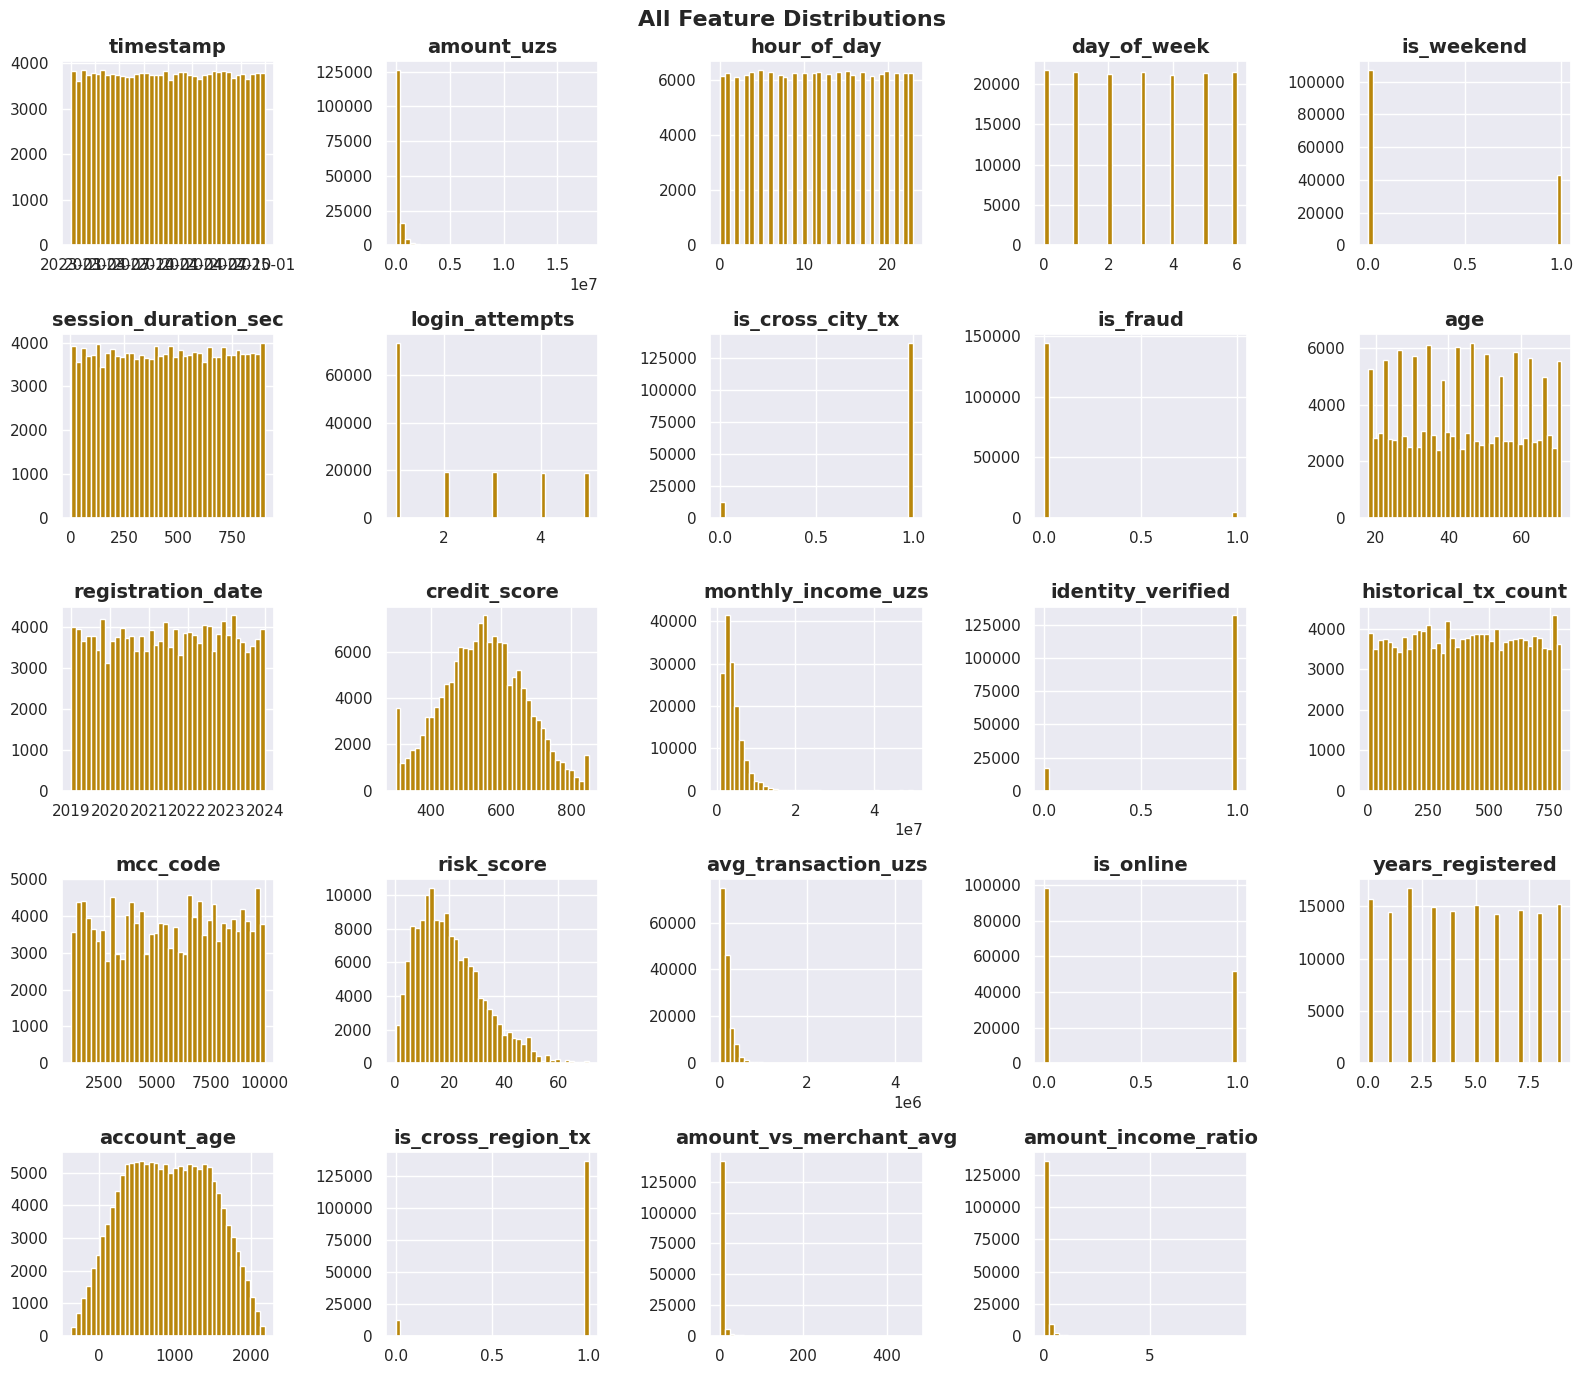

In [12]:
df.hist(figsize=(16, 14), bins=40)
plt.suptitle("All Feature Distributions")
plt.tight_layout()
plt.show()

Notable analysis:

/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y=col, ax=ax, palette=["darkgoldenrod", "gray"])
/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y=col, ax=ax, palette=["darkgoldenrod", "gray"])
/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y=col, ax=ax, palette=["darkgoldenrod", "gray"])
/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without as

/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y=col, ax=ax, palette=["darkgoldenrod", "gray"])
/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y=col, ax=ax, palette=["darkgoldenrod", "gray"])
/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y=col, ax=ax, palette=["darkgoldenrod", "gray"])
/tmp/ipykernel_86634/412356181.py:8: FutureWarning: 

Passing `palette` without as

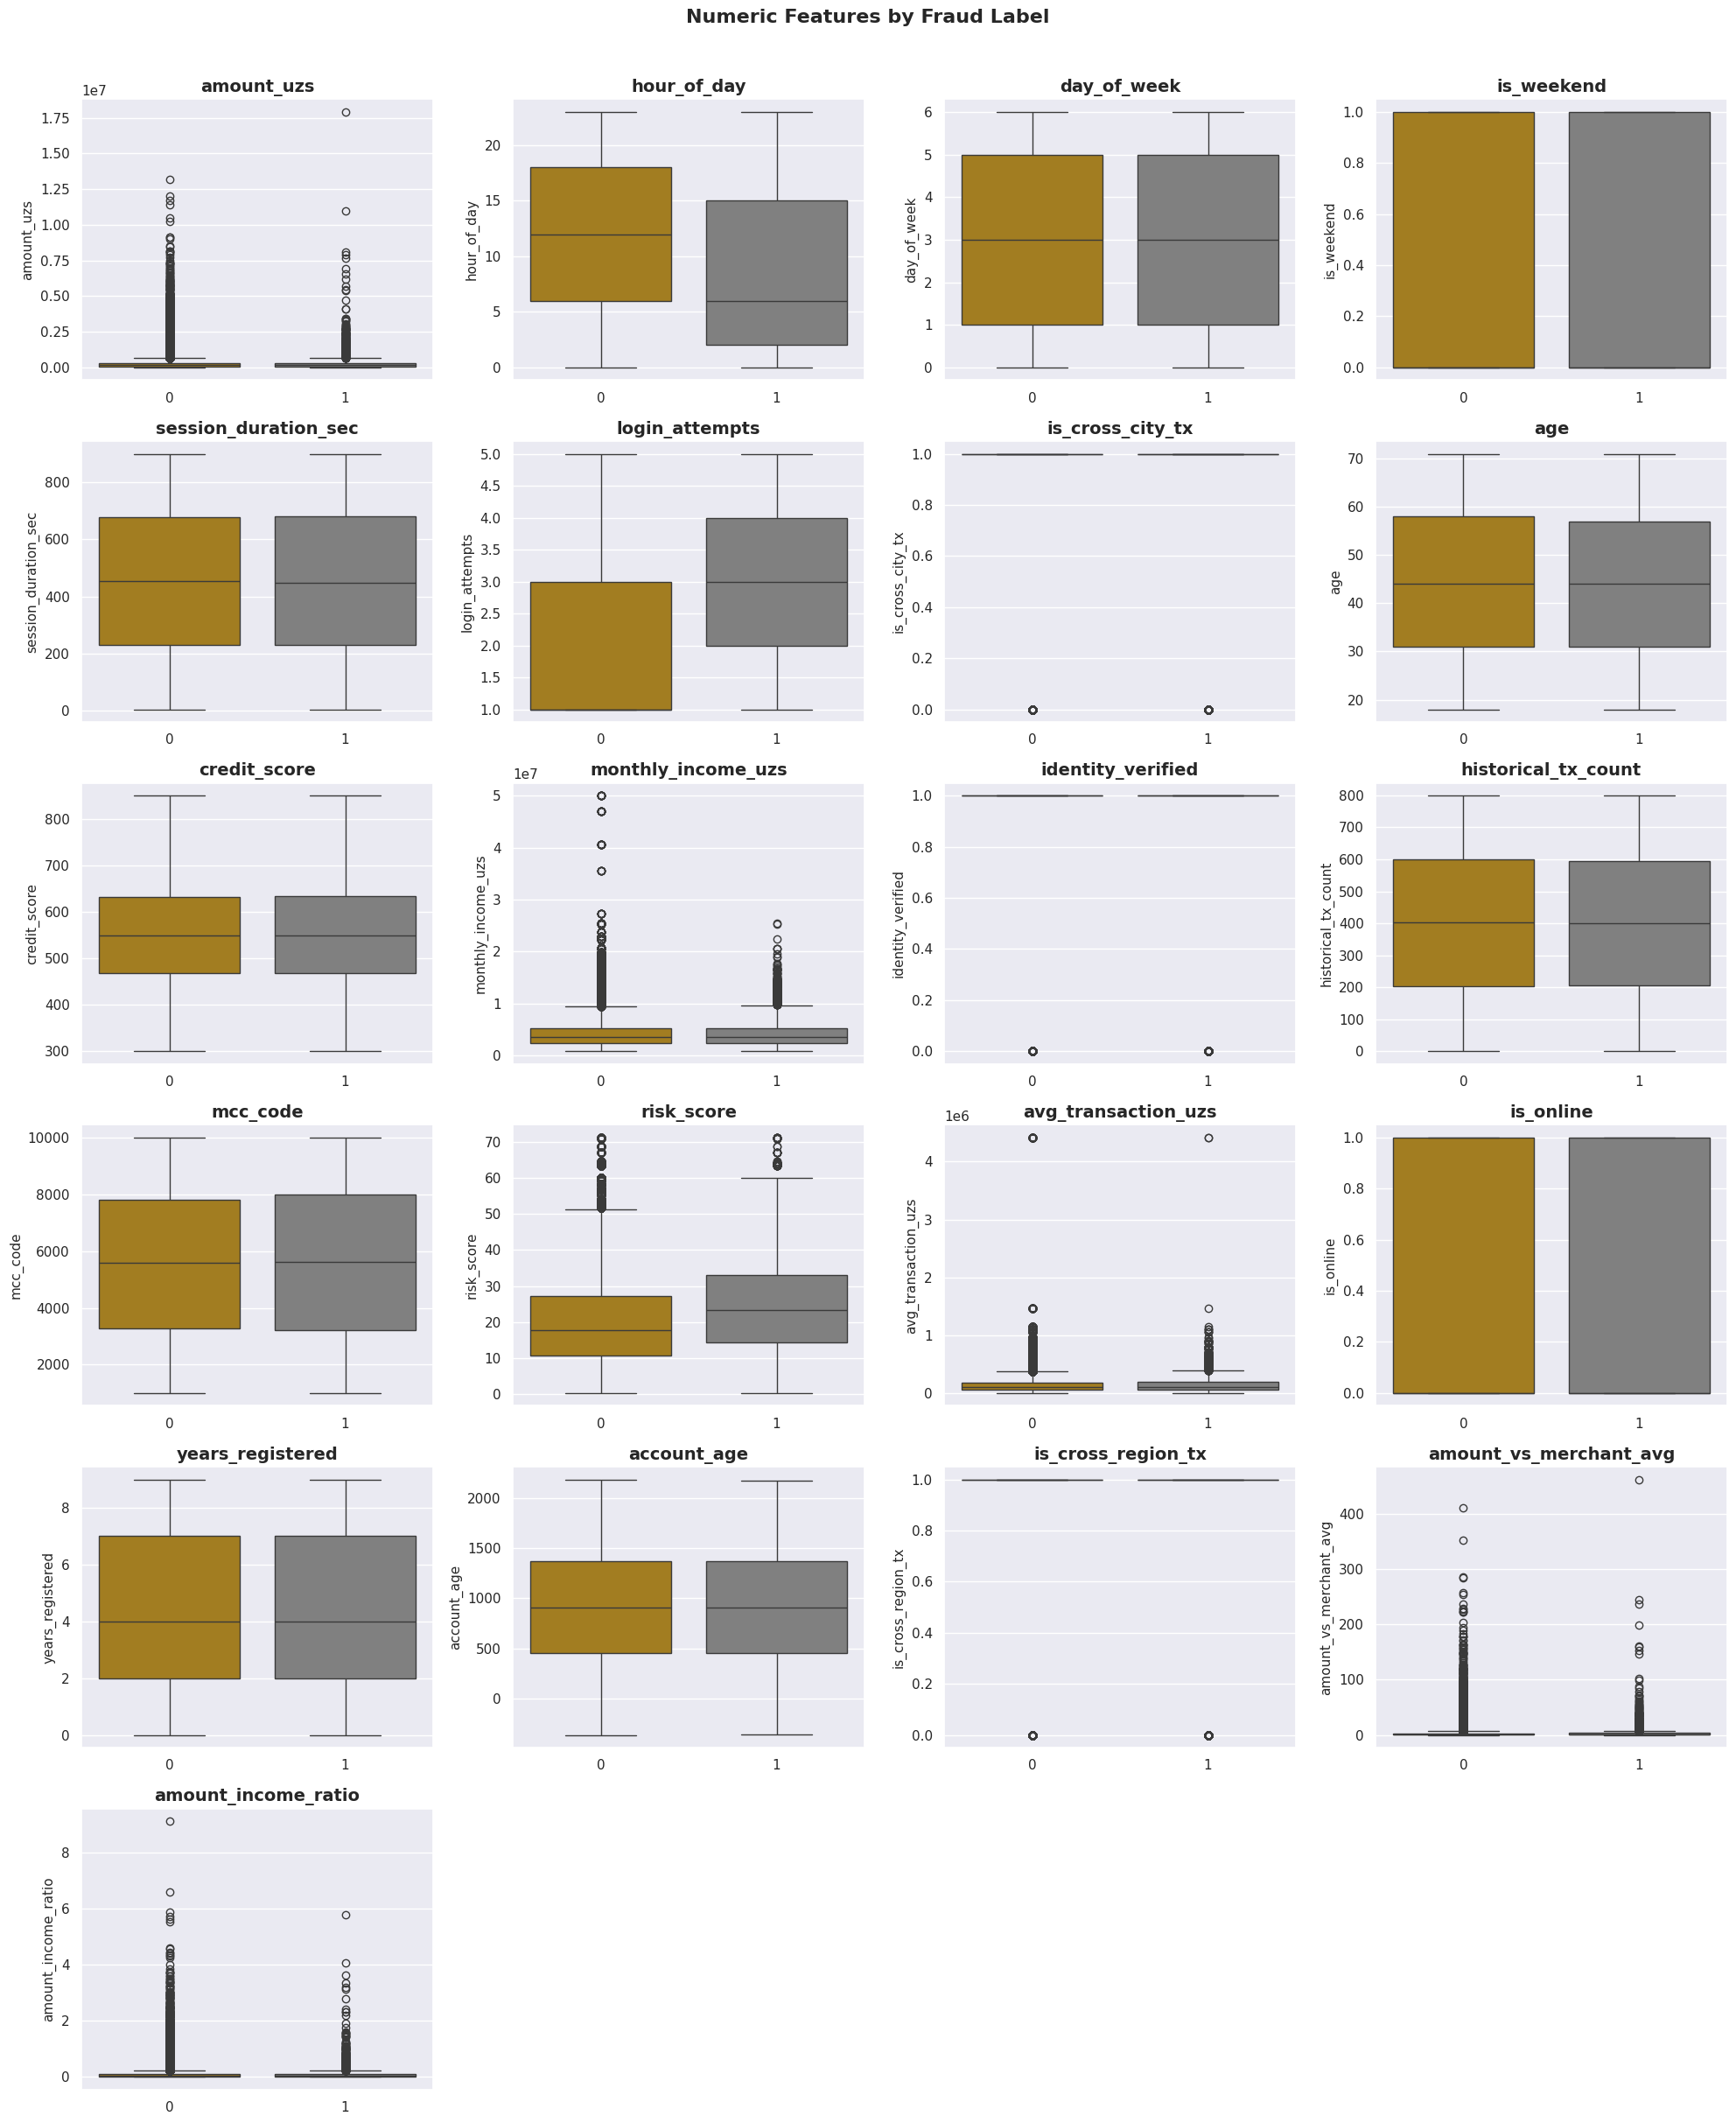

In [13]:
ncols = 4
nrows = math.ceil(len(num_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="is_fraud", y=col, ax=ax, palette=["darkgoldenrod", "gray"])
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(num_cols) :]:
    ax.set_visible(False)

plt.suptitle("Numeric Features by Fraud Label", y=1.01)
plt.tight_layout()
plt.show()

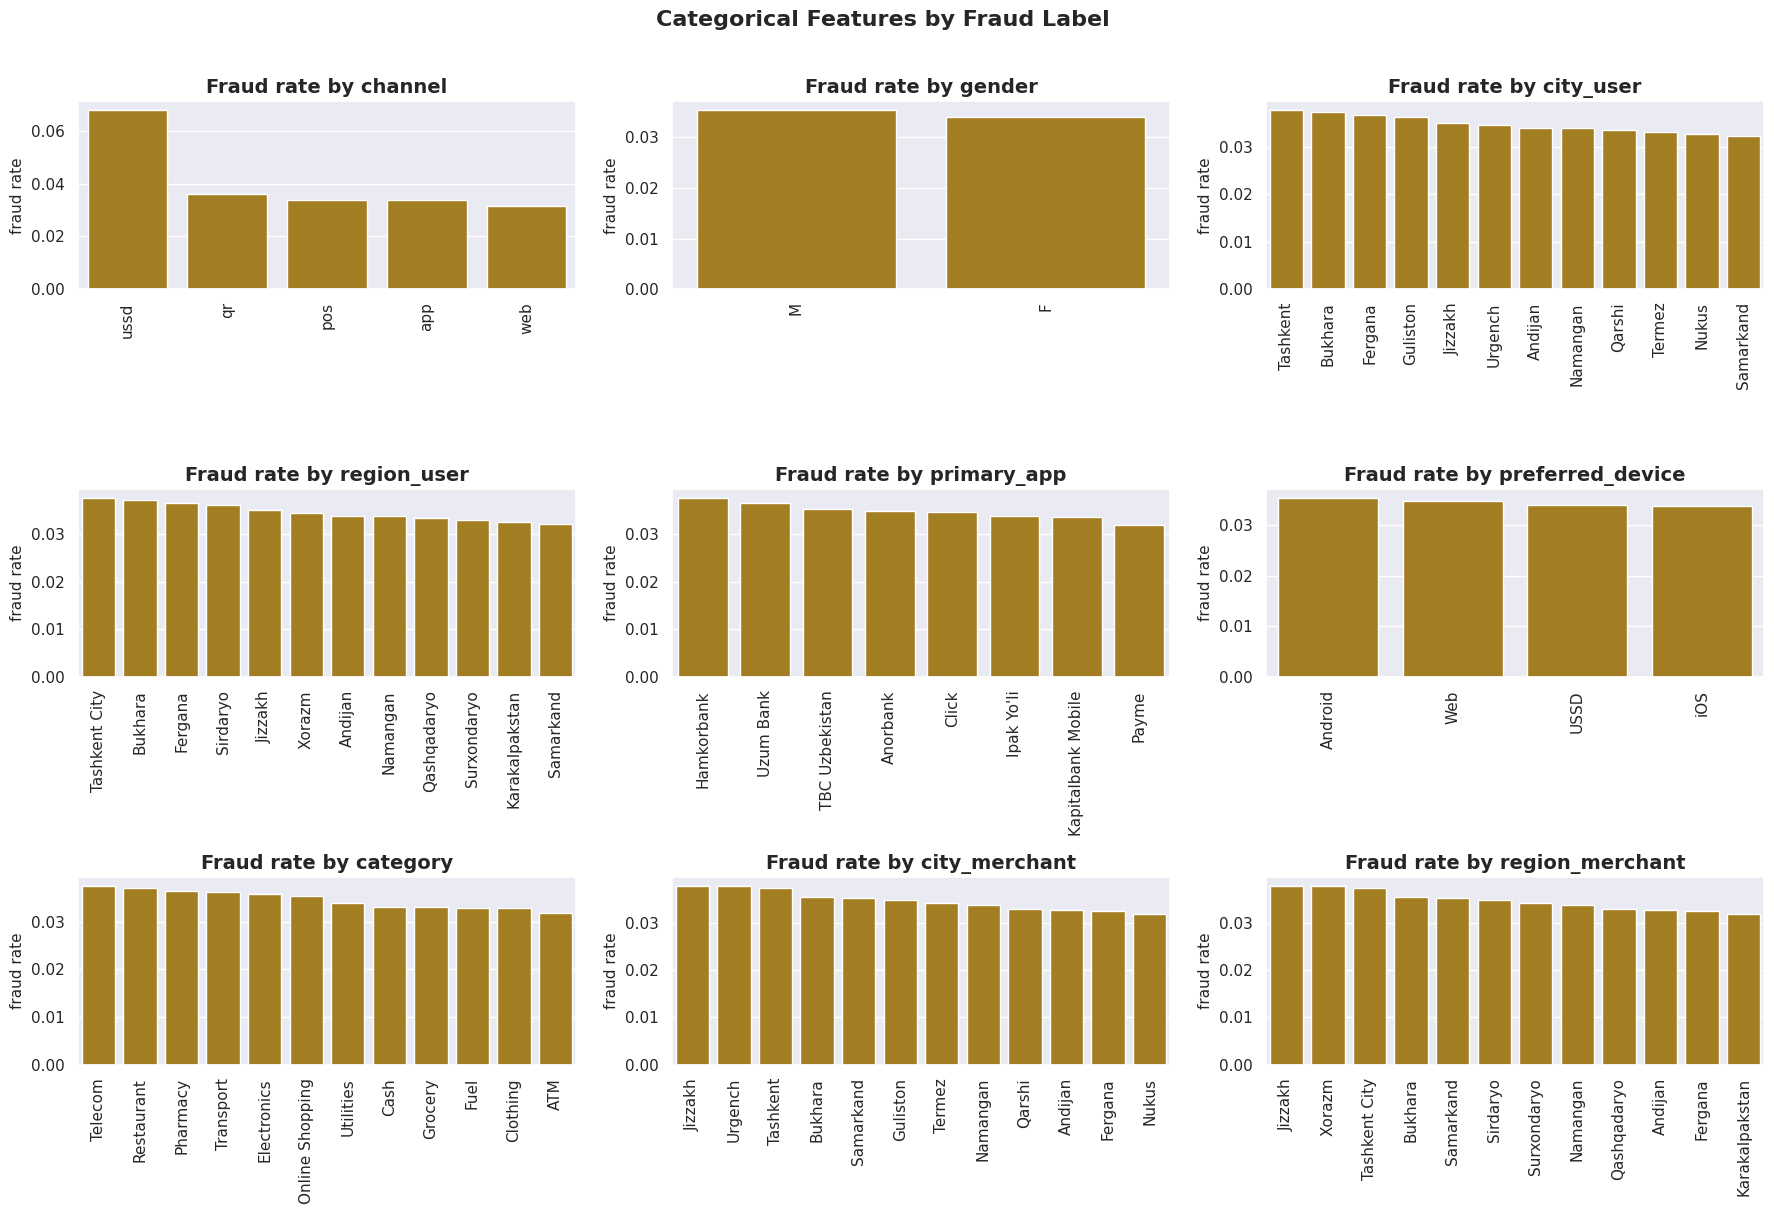

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    fraud_rate = df.groupby(col)["is_fraud"].mean().sort_values(ascending=False)
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values, ax=ax)
    ax.set_title(f"Fraud rate by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("fraud rate")
    ax.tick_params(axis="x", rotation=90)

plt.suptitle("Categorical Features by Fraud Label", y=1.01)
plt.tight_layout()
plt.show()

### Correlations

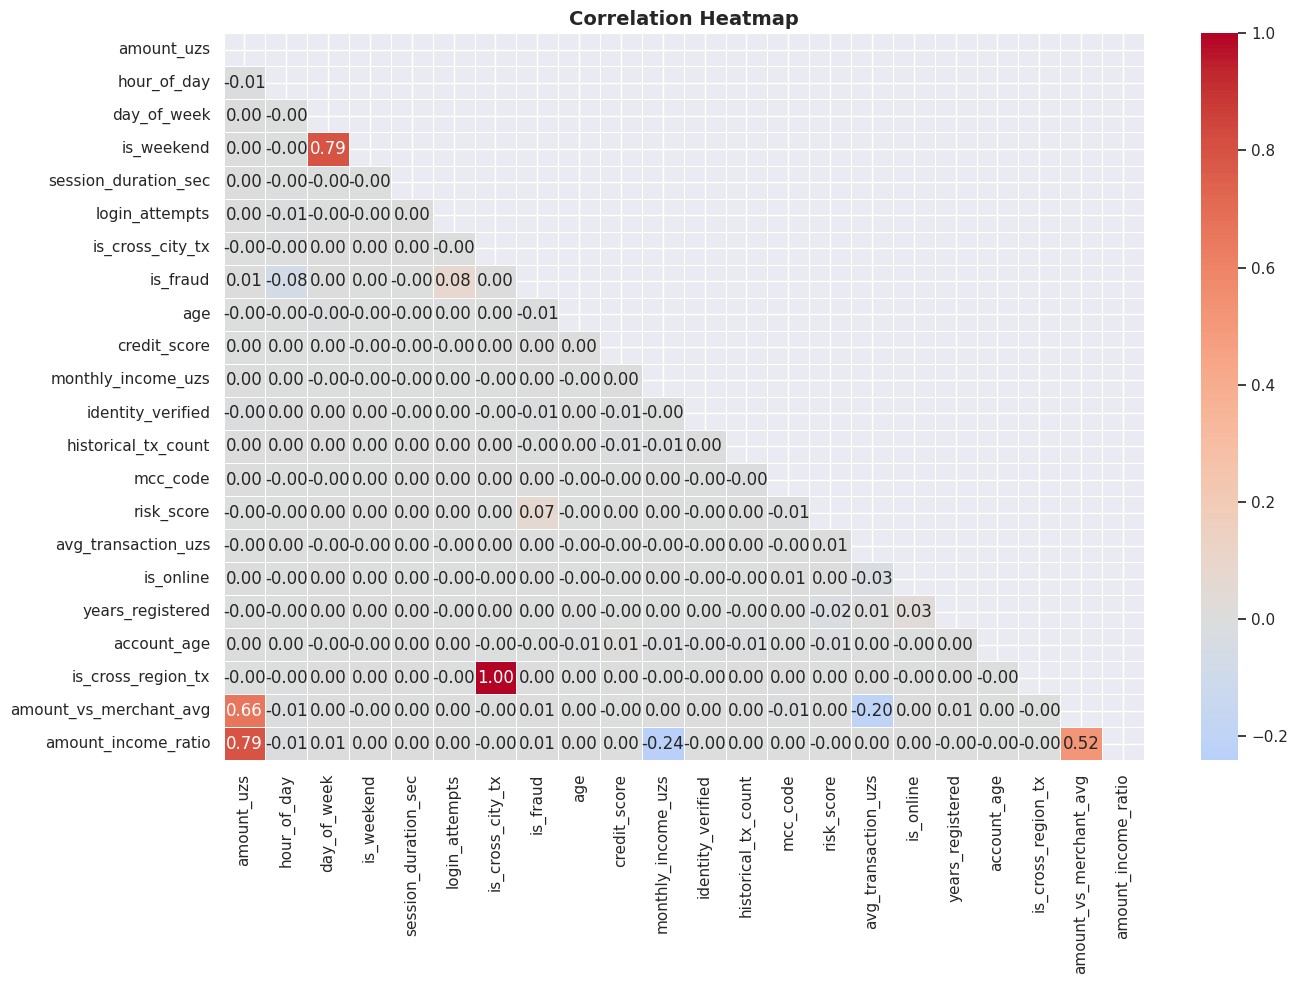

In [15]:
corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

We will keep both cross-region and cross-city checks even if signal strength is similar, it can flag different fraud patterns to cover both local anomalies & broader geographic anomalies

Correlations with Fraud

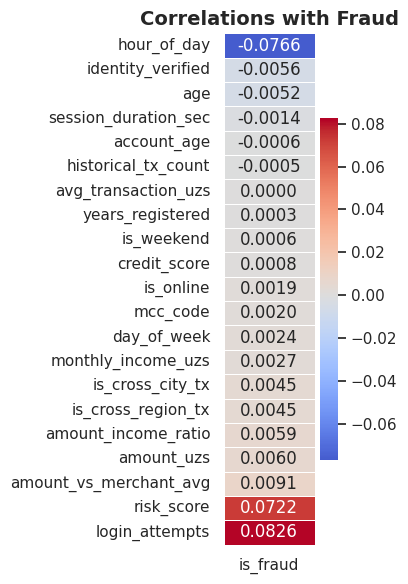

In [16]:
corr_fraud = (
    df.select_dtypes(include="number").corr()["is_fraud"].drop("is_fraud").sort_values()
)

fig, ax = plt.subplots(figsize=(4, 6))
sns.heatmap(
    corr_fraud.to_frame(),
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
plt.title("Correlations with Fraud")
plt.tight_layout()
plt.show()

Now we will do further EDA on features with higher correlation:

## Modelling

### Data Preparation

#### Splitting - 70/15/15

In [17]:
df = df.sort_values("timestamp").reset_index(drop=True)

n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

In [18]:
X_train = train_df.drop(columns=["is_fraud"])
y_train = train_df["is_fraud"]

X_val = val_df.drop(columns=["is_fraud"])
y_val = val_df["is_fraud"]

X_test = test_df.drop(columns=["is_fraud"])
y_test = test_df["is_fraud"]

print(f"Train:      {X_train.shape[0]:,} rows ({len(X_train)/len(df):.0%})")
print(f"Validation: {X_val.shape[0]:,} rows ({len(X_val)/len(df):.0%})")
print(f"Test:       {X_test.shape[0]:,} rows ({len(X_test)/len(df):.0%})")

print(
    f"\nFraud rate - train: {y_train.mean():.2%} | "
    f"val: {y_val.mean():.2%} | test: {y_test.mean():.2%}"
)

Train:      105,000 rows (70%)
Validation: 22,500 rows (15%)
Test:       22,500 rows (15%)

Fraud rate - train: 3.45% | val: 3.56% | test: 3.48%


#### 🔧 Preprocessing Pipeline 

Handling class imbalance: 
- Balanced class weights
- Threshold tuning

In [19]:
drop_cols = [
    "tx_id",
    "user_id",
    "merchant_id",
    "merchant_name",
    "name",
    "timestamp",
    "registration_date",
]

low_card_cats = ["gender", "channel", "preferred_device"]
high_card_cats = [
    "city_user",
    "city_merchant",
    "region_user",
    "region_merchant",
    "primary_app",
    "category",
    "mcc_code",
]

num_cols = X_train.select_dtypes(include="number").columns.tolist()
num_cols.remove("mcc_code")

In [20]:
print("drop:", drop_cols)
print("low_card:", low_card_cats)
print("high_card:", high_card_cats)
print("numeric:", num_cols)

all_handled = drop_cols + low_card_cats + high_card_cats + num_cols
unhandled = [c for c in X_train.columns if c not in all_handled]
print("unhandled:", unhandled)

drop: ['tx_id', 'user_id', 'merchant_id', 'merchant_name', 'name', 'timestamp', 'registration_date']
low_card: ['gender', 'channel', 'preferred_device']
high_card: ['city_user', 'city_merchant', 'region_user', 'region_merchant', 'primary_app', 'category', 'mcc_code']
numeric: ['amount_uzs', 'hour_of_day', 'day_of_week', 'is_weekend', 'session_duration_sec', 'login_attempts', 'is_cross_city_tx', 'age', 'credit_score', 'monthly_income_uzs', 'identity_verified', 'historical_tx_count', 'risk_score', 'avg_transaction_uzs', 'is_online', 'years_registered', 'account_age', 'is_cross_region_tx', 'amount_vs_merchant_avg', 'amount_income_ratio']
unhandled: []


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("drop", "drop", drop_cols),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_card_cats,
        ),
        ("target_enc", TargetEncoder(), high_card_cats),
        ("num", StandardScaler(), num_cols),
    ]
)

### Naive Baseline

In [22]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)

y_pred_train = dummy.predict(X_train)
y_pred_val = dummy.predict(X_val)

y_proba_train = dummy.predict_proba(X_train)[:, 1]
y_proba_val = dummy.predict_proba(X_val)[:, 1]

results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    y_proba_train,
    y_proba_val,
    model_name="Dummy (stratified)",
    params={"strategy": "stratified"},
)
results

,Model,Recall,Train Recall,PR AUC,F1 Score,Precision,Params
0,Dummy (stratified),0.031172,0.035626,0.035514,0.031309,0.031447,{'strategy': 'stratified'}


### Default Models

In [23]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=3000,
        class_weight="balanced",
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42, class_weight="balanced_subsample", n_estimators=300
    ),
    "Light Gradient Boosting": LGBMClassifier(
        random_state=42, is_unbalance=True, verbose=-1
    ),
    "Extreme Gradient Boosting": XGBClassifier(
        random_state=42,
        scale_pos_weight=int((y_train == 0).sum() / (y_train == 1).sum()),
    ),
}

In [24]:
pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline

    y_proba_train = pipeline.predict_proba(X_train)[:, 1]
    y_proba_val = pipeline.predict_proba(X_val)[:, 1]

    y_pred_train = pipeline.predict(X_train)
    y_pred_val = pipeline.predict(X_val)

    results, display_results = score_predictions(
        y_pred_train,
        y_pred_val,
        y_train,
        y_val,
        y_proba_train,
        y_proba_val,
        f"Base {name}",
        "Defaults",
        results,
    )

display_results

,Model,Recall,Train Recall,PR AUC,F1 Score,Precision,Params
0,Base Logistic Regression,0.642,0.641,0.078,0.121,0.067,Defaults
1,Base Light Gradient Boosting,0.595,0.784,0.087,0.139,0.079,Defaults
2,Base Extreme Gradient Boosting,0.283,0.815,0.068,0.121,0.077,Defaults
3,Dummy (stratified),0.031,0.036,0.036,0.031,0.031,{'strategy': 'stratified'}
4,Base Random Forest,0.000,0.038,0.083,0.000,0.000,Defaults


### Tuned Light Gradient Boosting

In [25]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# study_lgbm = optuna.create_study(
#     direction="maximize",
#     sampler=TPESampler(seed=42),
#     pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
# )

# study_lgbm.optimize(
#     lambda trial: objective_lgbm(
#         trial,
#         preprocessor=preprocessor,
#         X_train=X_train,
#         y_train=y_train,
#         cv=cv,
#     ),
#     n_trials=50,
#     n_jobs=-1,
# )

# print(f"Best Recall: {study_lgbm.best_value:.4f}")
# print(f"Best params: {study_lgbm.best_params}")
# best_params_lgbm = study_lgbm.best_params

In [26]:
best_params_lgbm = {
    "n_estimators": 561,
    "learning_rate": 0.01127602630960333,
    "max_depth": 3,
    "num_leaves": 86,
    "min_child_samples": 33,
    "subsample": 0.6397335385458072,
    "colsample_bytree": 0.6831879491710622,
    "reg_alpha": 9.599611462272622e-06,
    "reg_lambda": 7.762055523398278e-08,
}

In [27]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
lgbm_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMClassifier(
                **best_params_lgbm,
                # is_unbalance=True,
                scale_pos_weight=scale,
                random_state=42,
                verbose=-1,
            ),
        ),
    ]
)
lgbm_pipeline.fit(X_train, y_train)
pipelines["Tuned LGBM"] = lgbm_pipeline

y_proba_train = lgbm_pipeline.predict_proba(X_train)[:, 1]
y_proba_val = lgbm_pipeline.predict_proba(X_val)[:, 1]
y_pred_train = lgbm_pipeline.predict(X_train)
y_pred_val = lgbm_pipeline.predict(X_val)

results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    y_proba_train,
    y_proba_val,
    "Tuned LGBM",
    best_params_lgbm,
    results,
)

new_results

,Model,Recall,Train Recall,PR AUC,F1 Score,Precision,Params
0,Tuned LGBM,0.706,0.725,0.105,0.137,0.076,"{'n_estimators': 561, 'learning_rate': 0.01127..."
1,Base Logistic Regression,0.642,0.641,0.078,0.121,0.067,Defaults
2,Base Light Gradient Boosting,0.595,0.784,0.087,0.139,0.079,Defaults
3,Base Extreme Gradient Boosting,0.283,0.815,0.068,0.121,0.077,Defaults
4,Dummy (stratified),0.031,0.036,0.036,0.031,0.031,{'strategy': 'stratified'}
5,Base Random Forest,0.000,0.038,0.083,0.000,0.000,Defaults


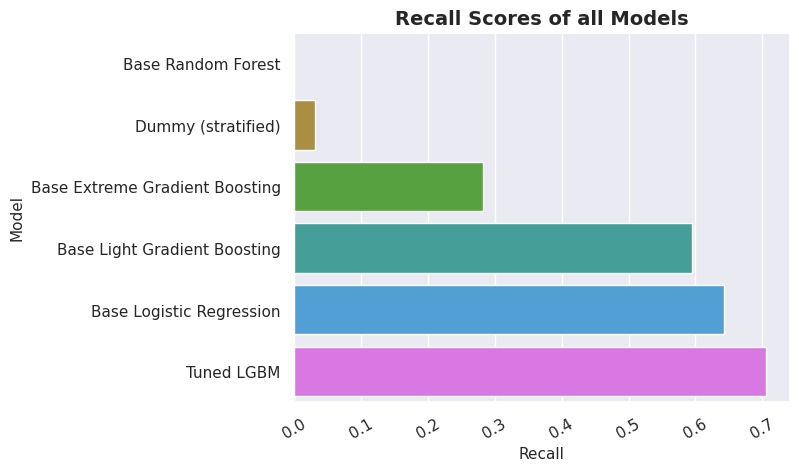

In [28]:
ax = sns.barplot(
    results.sort_values("Recall", ascending=False).iloc[::-1],
    x="Recall",
    y="Model",
    hue="Model",
)
plt.title("Recall Scores of all Models")
plt.xticks(rotation=30)
plt.show()

Threshold Tuning

Having a recall floor of 0.80 to ensure we don't miss too much fraud. At the same time also maximizing precision within that constraint, not flagging every transaction.

In [29]:
precs, recs, thresholds = precision_recall_curve(y_val, y_proba_val)
min_recall = 0.80
valid = recs[:-1] >= min_recall
best_thresh = thresholds[valid][np.argmax(precs[:-1][valid])]
print(f"Best threshold: {best_thresh:.4f}")

Best threshold: 0.4304


The optimal threshold is ~0.4, slightly below the default 0.5. The model needs a bit less confidence to flag something as fraud where missing a case is costly.

In [30]:
y_proba_val = lgbm_pipeline.predict_proba(X_val)[:, 1]
y_pred_train = (y_proba_train >= best_thresh).astype(int)
y_pred_val = (y_proba_val >= best_thresh).astype(int)

results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    y_proba_train,
    y_proba_val,
    "[Val] Tuned LGBM Threshold",
    best_params_lgbm,
    results,
)

In [31]:
y_proba_test = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred_train = (y_proba_train >= best_thresh).astype(int)
y_pred_test = (y_proba_test >= best_thresh).astype(int)

results, new_results = score_predictions(
    y_pred_train,
    y_pred_test,
    y_train,
    y_test,
    y_proba_train,
    y_proba_test,
    "[Test] Tuned LGBM Threshold",
    best_params_lgbm,
    results,
)
new_results

,Model,Recall,Train Recall,PR AUC,F1 Score,Precision,Params
0,[Val] Tuned LGBM Threshold,0.800,0.838,0.105,0.115,0.062,"{'n_estimators': 561, 'learning_rate': 0.01127..."
1,[Test] Tuned LGBM Threshold,0.783,0.838,0.099,0.111,0.060,"{'n_estimators': 561, 'learning_rate': 0.01127..."
2,Tuned LGBM,0.706,0.725,0.105,0.137,0.076,"{'n_estimators': 561, 'learning_rate': 0.01127..."
3,Base Logistic Regression,0.642,0.641,0.078,0.121,0.067,Defaults
4,Base Light Gradient Boosting,0.595,0.784,0.087,0.139,0.079,Defaults
5,Base Extreme Gradient Boosting,0.283,0.815,0.068,0.121,0.077,Defaults
6,Dummy (stratified),0.031,0.036,0.036,0.031,0.031,{'strategy': 'stratified'}
7,Base Random Forest,0.000,0.038,0.083,0.000,0.000,Defaults


#### Stacked Model

In [32]:
estimators = [
    (
        "lgbm",
        LGBMClassifier(
            **best_params_lgbm,
            is_unbalance=True,
            random_state=42,
            verbose=-1,
        ),
    ),
    # (
    #     "xgb",
    #     XGBClassifier(
    #         **best_params_xgb,
    #         scale_pos_weight=int((y_train == 0).sum() / (y_train == 1).sum()),
    #         random_state=42,
    #         verbosity=0,
    #     ),
    # ),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

pipeline_stack = Pipeline([("preprocessor", preprocessor), ("model", stack)])
pipeline_stack.fit(X_train, y_train)
pipelines["Stacking"] = pipeline_stack

y_proba_train = pipeline_stack.predict_proba(X_train)[:, 1]
y_pred_train = (y_proba_train >= best_thresh).astype(int)
y_proba_val = pipeline_stack.predict_proba(X_val)[:, 1]
y_pred_val = (y_proba_val >= best_thresh).astype(int)


results, new_results = score_predictions(
    y_pred_train,
    y_pred_val,
    y_train,
    y_val,
    y_proba_train,
    y_proba_val,
    "Stacked LGBM + LR",
    "Best params LGBM + meta-learner LR",
    results,
)
new_results

,Model,Recall,Train Recall,PR AUC,F1 Score,Precision,Params
0,[Val] Tuned LGBM Threshold,0.800,0.838,0.105,0.115,0.062,"{'n_estimators': 561, 'learning_rate': 0.01127..."
1,Stacked LGBM + LR,0.796,0.839,0.107,0.116,0.062,Best params LGBM + meta-learner LR
2,[Test] Tuned LGBM Threshold,0.783,0.838,0.099,0.111,0.060,"{'n_estimators': 561, 'learning_rate': 0.01127..."
3,Tuned LGBM,0.706,0.725,0.105,0.137,0.076,"{'n_estimators': 561, 'learning_rate': 0.01127..."
4,Base Logistic Regression,0.642,0.641,0.078,0.121,0.067,Defaults
5,Base Light Gradient Boosting,0.595,0.784,0.087,0.139,0.079,Defaults
6,Base Extreme Gradient Boosting,0.283,0.815,0.068,0.121,0.077,Defaults
7,Dummy (stratified),0.031,0.036,0.036,0.031,0.031,{'strategy': 'stratified'}
8,Base Random Forest,0.000,0.038,0.083,0.000,0.000,Defaults


In [35]:
y_proba_test = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_thresh).astype(int)

results, new_results = score_predictions(
    y_pred_train,
    y_pred_test,
    y_train,
    y_test,
    y_proba_train,
    y_proba_test,
    "[Test] Stacked",
    best_params_lgbm,
    results,
)
new_results

,Model,Recall,Train Recall,PR AUC,F1 Score,Precision,Params
0,[Val] Tuned LGBM Threshold,0.800,0.838,0.105,0.115,0.062,"{'n_estimators': 561, 'learning_rate': 0.01127..."
1,Stacked LGBM + LR,0.796,0.839,0.107,0.116,0.062,Best params LGBM + meta-learner LR
2,[Test] Tuned LGBM Threshold,0.783,0.838,0.099,0.111,0.060,"{'n_estimators': 561, 'learning_rate': 0.01127..."
3,[Test] Stacked,0.783,0.839,0.099,0.111,0.060,"{'n_estimators': 561, 'learning_rate': 0.01127..."
4,Tuned LGBM,0.706,0.725,0.105,0.137,0.076,"{'n_estimators': 561, 'learning_rate': 0.01127..."
5,Base Logistic Regression,0.642,0.641,0.078,0.121,0.067,Defaults
6,Base Light Gradient Boosting,0.595,0.784,0.087,0.139,0.079,Defaults
7,Base Extreme Gradient Boosting,0.283,0.815,0.068,0.121,0.077,Defaults
8,Dummy (stratified),0.031,0.036,0.036,0.031,0.031,{'strategy': 'stratified'}
9,Base Random Forest,0.000,0.038,0.083,0.000,0.000,Defaults


## Feature Importance

In [33]:
feature_names = lgbm_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = lgbm_pipeline.named_steps["model"].feature_importances_
pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

num__risk_score                784
num__login_attempts            448
num__hour_of_day               381
target_enc__mcc_code           210
ohe__channel_ussd              210
num__amount_income_ratio       162
num__historical_tx_count       158
num__monthly_income_uzs        147
num__account_age               139
num__amount_vs_merchant_avg    138
dtype: int32

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

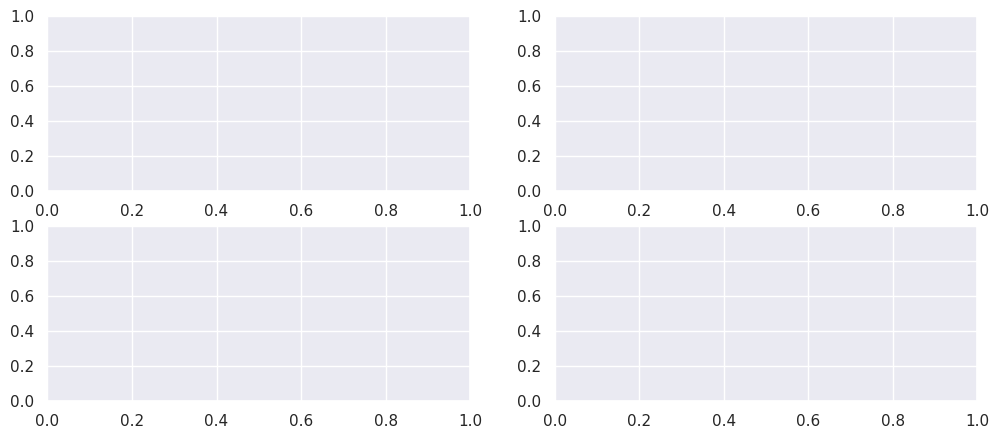

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))

for ax, (model_name, pipeline) in zip(axes, pipelines.items()):
    y_proba_val = pipeline.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_val)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    ax.plot(recalls, precisions)
    ax.scatter(
        recalls[best_idx],
        precisions[best_idx],
        color="darkgoldenrod",
        zorder=5,
        label=f"Best threshold: {best_threshold:.2f}",
    )
    ax.set_title(model_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

plt.suptitle("Precision-Recall Curves", y=1.01)
plt.tight_layout()
plt.show()